## Step 1: Understanding the Dataset

The Iris dataset contains 150 samples of iris flowers categorized into three species:
1. **Setosa** (Class 0)
2. **Versicolor** (Class 1)
3. **Virginica** (Class 2)

Each sample has four features:
- Sepal length (cm)
- Sepal width (cm)
- Petal length (cm)
- Petal width (cm)

**Objective**: Train machine learning models to classify iris flower species based on these features.

## Step 2: Importing Necessary Libraries

In [7]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 3: Loading the Iris Dataset

In [8]:
# Load iris dataset from sklearn
iris = load_iris()

# Create a DataFrame with the features and target
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target # Add the target variable

# Display the first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 4: Data Exploration and Cleaning

In [9]:
# Check the structure and summary of the DataFrame
print("--- Data Summary ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(f"Duplicates count: {df.duplicated().sum()}")

print("\n--- Data Types ---")
print(df.dtypes)

# Descriptive statistics
display(df.describe().transpose())

--- Data Summary ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

--- Missing Values ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

--- Duplicate Rows ---
Duplicates count: 1

--- Data Types ---
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
target                 int64
dtype: object


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5
target,150.0,1.000000,0.819232,0.0,0.0,1.00,2.0,2.0


## Step 5: Exploratory Data Analysis (EDA)

Target Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


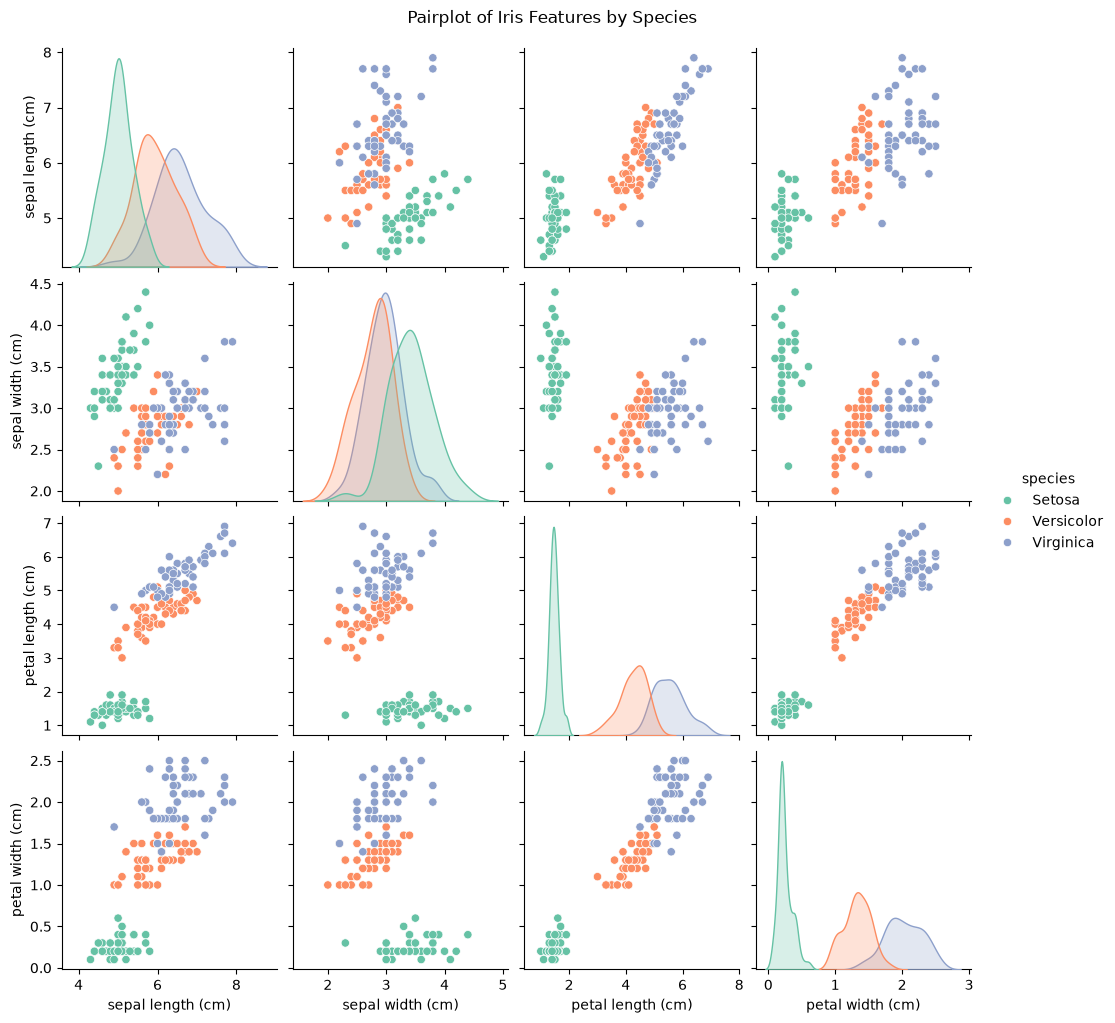

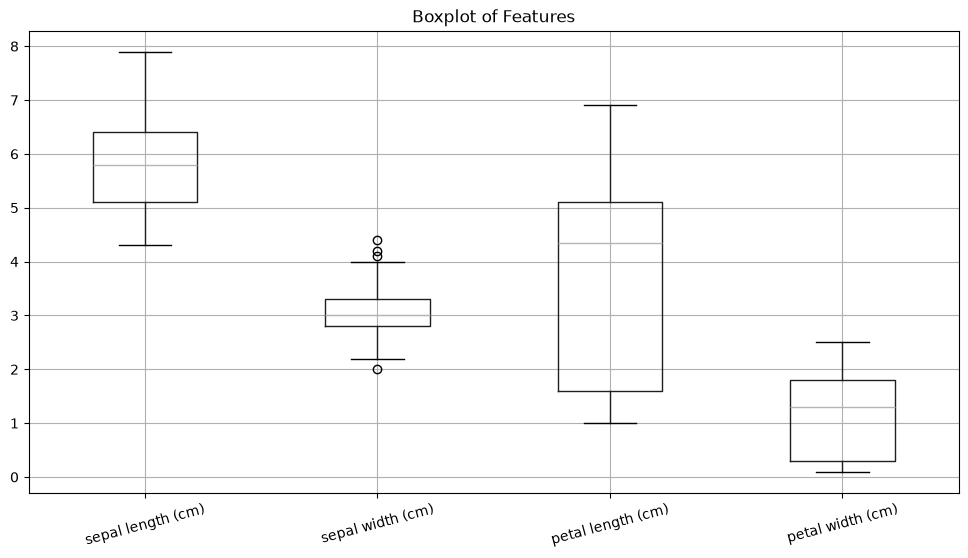

<Figure size 1000x800 with 0 Axes>

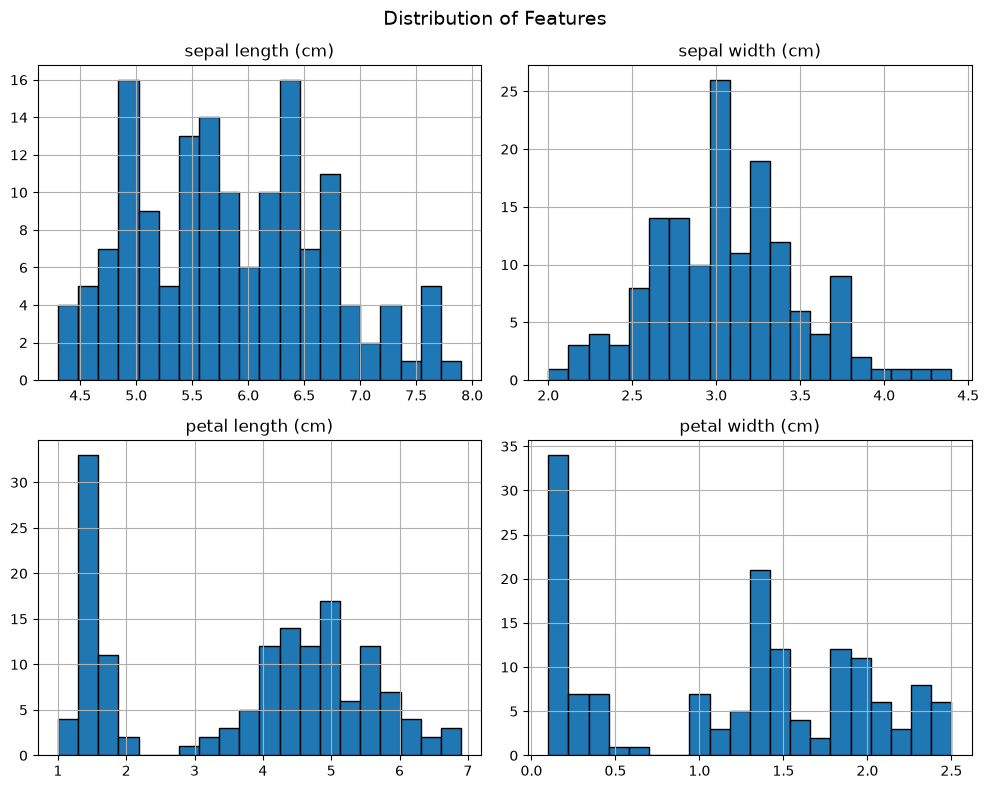

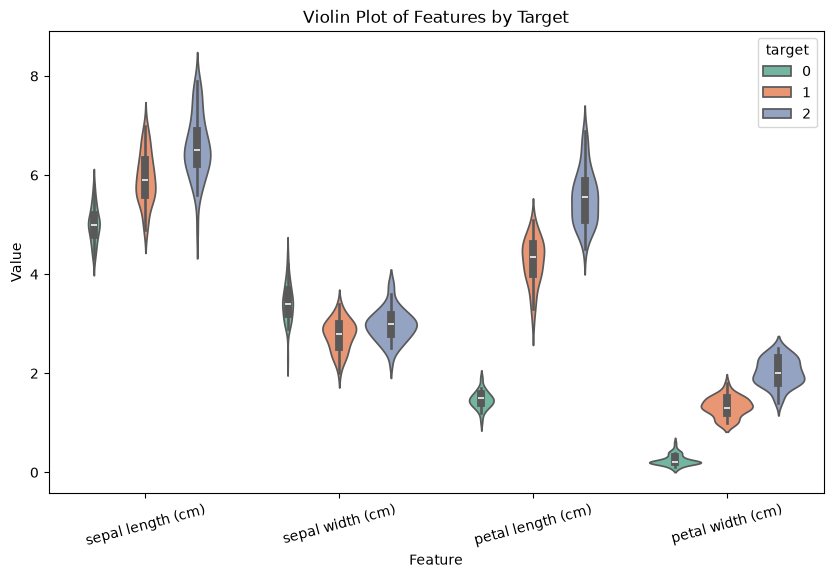

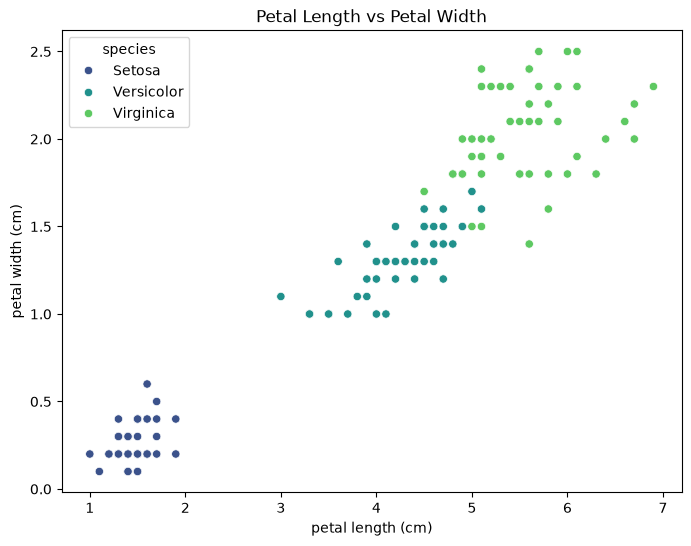

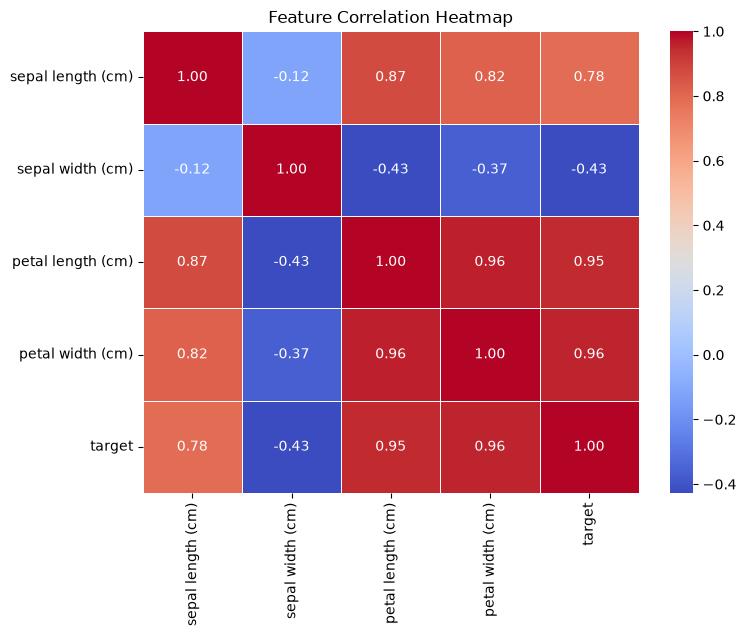

In [10]:
# Count sample size in each target class
print("Target Class Distribution:")
print(df['target'].value_counts())

# Map numerical target labels to flower species names for plotting
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# 1. Pairplot
sns.pairplot(df.drop(columns=['target']), hue='species', palette='Set2')
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

# 2. Boxplot
plt.figure(figsize=(12, 6))
df.drop(columns=['target', 'species']).boxplot()
plt.title("Boxplot of Features")
plt.xticks(rotation=15)
plt.show()

# 3. Histograms
plt.figure(figsize=(10, 8))
df.drop(columns=['target', 'species']).hist(bins=20, edgecolor='black', figsize=(10, 8))
plt.suptitle("Distribution of Features", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Violin Plot
df_melted = df.drop(columns=['species']).melt(id_vars=['target'], var_name='Feature', value_name='Value')
plt.figure(figsize=(10, 6))
sns.violinplot(x="Feature", y="Value", hue="target", data=df_melted, palette="Set2")
plt.xticks(rotation=15)
plt.title("Violin Plot of Features by Target")
plt.show()

# 5. Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['petal length (cm)'], y=df['petal width (cm)'], hue=df['species'], palette="viridis")
plt.title("Petal Length vs Petal Width")
plt.show()

# 6. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['species']).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## Step 6: Splitting the Data

In [11]:
# X contains input features, y contains target label
X = df.drop(columns=['target', 'species'])
y = df['target']

# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (120, 4)
Testing set shape: (30, 4)


## Step 7: Feature Scaling

In [12]:
# Standardize features using StandardScaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

## Step 8: Model Training & Evaluation

In [13]:
# 1. Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

accuracy_log_reg = accuracy_score(y_test, y_pred_log)
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log)
class_report_log_reg = classification_report(y_test, y_pred_log)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.2f}")
print("Confusion Matrix:\n", conf_matrix_log_reg)
print("Classification Report:\n", class_report_log_reg)

# 2. Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_scaled, y_train)
y_pred_tree = tree_clf.predict(X_test_scaled)

accuracy_tree = accuracy_score(y_test, y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
class_report_tree = classification_report(y_test, y_pred_tree)

print(f"\nDecision Tree Accuracy: {accuracy_tree:.2f}")
print("Confusion Matrix:\n", conf_matrix_tree)
print("Classification Report:\n", class_report_tree)

# 3. k-Nearest Neighbors (k-NN)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn)

print(f"\nk-NN Accuracy: {accuracy_knn:.2f}")
print("Confusion Matrix:\n", conf_matrix_knn)
print("Classification Report:\n", class_report_knn)

Logistic Regression Accuracy: 1.00
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Decision Tree Accuracy: 1.00
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


k-NN Accurac

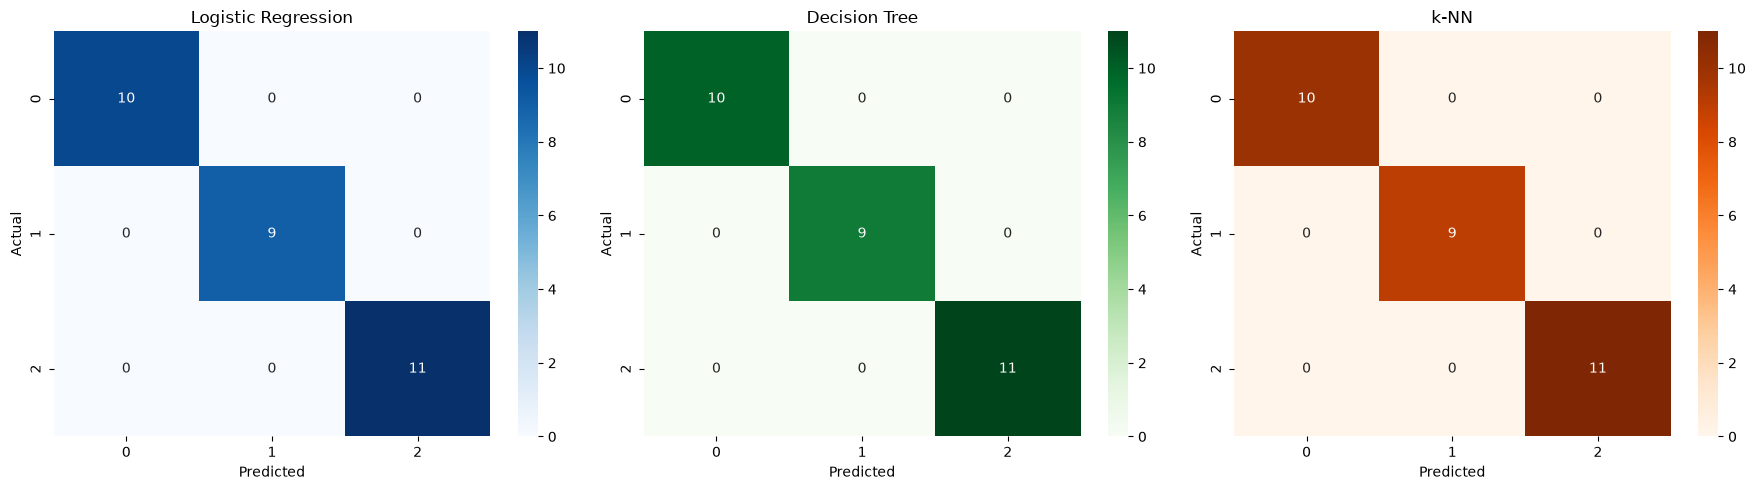

In [14]:
# Visualizing Confusion Matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# k-NN
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('k-NN')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Step 9: Saving the Best Model & Scaler

In [15]:
# Save trained model and scaler to pickle files
with open('iris_model.pkl', 'wb') as model_file:
    pickle.dump(log_reg, model_file)

with open('iris_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Model 'iris_model.pkl' and Scaler 'iris_scaler.pkl' saved successfully!")

Model 'iris_model.pkl' and Scaler 'iris_scaler.pkl' saved successfully!


## Step 10: Inferencing Function & Example Usage

In [16]:
def load_model_and_scaler(model_filename='iris_model.pkl', scaler_filename='iris_scaler.pkl'):
    """Loads trained model and scaler from pickle files."""
    with open(model_filename, 'rb') as model_file:
        model = pickle.load(model_file)
    with open(scaler_filename, 'rb') as scaler_file:
        scaler = pickle.load(scaler_file)
    return model, scaler

def preprocess_input(input_data, scaler):
    """Converts input dictionary to DataFrame and scales features."""
    input_df = pd.DataFrame([input_data])
    input_scaled = scaler.transform(input_df)
    return input_scaled

def predict_iris_species(input_data):
    """Predicts species (Setosa, Versicolor, Virginica) for given input."""
    model, scaler = load_model_and_scaler()
    input_scaled = preprocess_input(input_data, scaler)
    prediction = model.predict(input_scaled)
    species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
    return species_map[prediction[0]]

# Example Usage
new_iris_data = {
    'sepal length (cm)': 5.1,
    'sepal width (cm)': 3.5,
    'petal length (cm)': 1.4,
    'petal width (cm)': 0.2
}

result = predict_iris_species(new_iris_data)
print(f"The predicted species is: {result}")

The predicted species is: setosa
